In [1]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

from matplotlib import pyplot as plt

In [2]:
is_cuda = torch.cuda.is_available()
device = torch.device('cuda' if is_cuda else 'cpu')

print(f'Current cuda device is', device)

Current cuda device is cuda


In [3]:
batch_size = 50
epoch_num = 15
learning_rate = 0.0001

In [4]:
os.getcwd()

'/content'

In [5]:
os.path.isdir('/content/data')

False

In [6]:
if not os.path.isdir('/content/data'):
  os.mkdir('data')

In [7]:
train_data = datasets.MNIST(root= './data', train = True, download = True,
                            transform = transforms.ToTensor())
test_data = datasets.MNIST(root= './data', train = False, download = True,
                            transform = transforms.ToTensor())

print(f'number of training data : {len(train_data)}')
print(f'number of test data : {len(test_data)}')

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.66MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.88MB/s]

number of training data : 60000
number of test data : 10000


In [8]:
image, label = train_data[0]

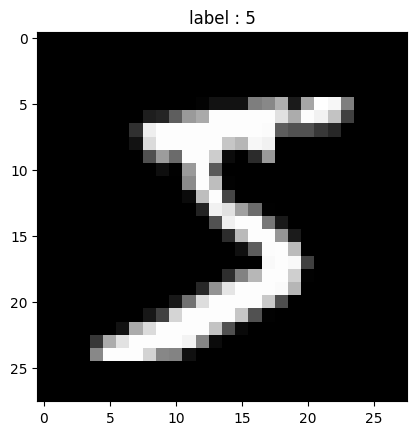

In [9]:
plt.imshow(image.squeeze().numpy(), cmap = 'gray')
plt.title(f'label : {label}')
plt.show()

In [10]:
train_loader = torch.utils.data.DataLoader(dataset = train_data,
                                           batch_size = batch_size,
                                           shuffle = True)

trest_loader = torch.utils.data.DataLoader(dataset = test_data,
                                           batch_size = batch_size,
                                           shuffle = True)

In [11]:
first_batch = train_loader.__iter__().__next__()

print(f'{ "name":<15} | { "type":<25} | {"size"}')
print(f'{ "Num of Batch":<15} | { "":<25} | {len(train_loader)}')
print(f'{ "first_batch":<15} | { str(type(first_batch)):<25} | {len(first_batch)}')
print(f'{ "first_batch[0]":<15} | { str(type(first_batch[0])) :<25} | {first_batch[0].shape} ')
print(f'{ "first_batch[1]":<15} | { str(type(first_batch[1])) :<25} | {first_batch[1].shape} ')

name            | type                      | size
Num of Batch    |                           | 1200
first_batch     | <class 'list'>            | 2
first_batch[0]  | <class 'torch.Tensor'>    | torch.Size([50, 1, 28, 28]) 
first_batch[1]  | <class 'torch.Tensor'>    | torch.Size([50]) 


In [18]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 32, 3, 1)
    self.conv2 = nn.Conv2d(32, 64, 3, 1)
    self.dropout1 = nn.Dropout2d(0.25)
    self.dropout2 = nn.Dropout2d(0.5)
    self.fc1 = nn.Linear(9216, 128)
    self.fc2 = nn.Linear(128, 10)

  def forward(self, x):
    x = self.conv1(x)
    x = F.relu(x)
    x = self.conv2(x)
    x = F.relu(x)
    x = F.max_pool2d(x, 2)
    x = self.dropout1(x)
    x = torch.flatten(x, 1)
    x = self.fc1(x)
    x = F.relu(x)
    x = self.dropout2(x)
    x = self.fc2(x)
    output = F.log_softmax(x, dim = 1)
    return output

In [19]:
model = CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr = learning_rate)
criterion = nn.CrossEntropyLoss()

In [20]:
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (dropout2): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [21]:
model.train()
i = 0
for epoch in range(epoch_num):
  for data, target in train_loader:
    data = data.to(device)
    target = target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()
    if i % 1000 == 0:
      print(f'Train Step : {i}\tLoss : {loss.item():.3f}')
    i += 1

/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Train Step : 0	Loss : 2.303
Train Step : 1000	Loss : 0.382
Train Step : 2000	Loss : 0.206
Train Step : 3000	Loss : 0.099
Train Step : 4000	Loss : 0.136
Train Step : 5000	Loss : 0.172
Train Step : 6000	Loss : 0.100
Train Step : 7000	Loss : 0.073
Train Step : 8000	Loss : 0.109
Train Step : 9000	Loss : 0.122
Train Step : 10000	Loss : 0.039
Train Step : 11000	Loss : 0.027
Train Step : 12000	Loss : 0.063
Train Step : 13000	Loss : 0.131
Train Step : 14000	Loss : 0.109
Train Step : 15000	Loss : 0.013
Train Step : 16000	Loss : 0.031
Train Step : 17000	Loss : 0.020


In [24]:
model.eval()
correct = 0

for data, target in trest_loader:
  data = data.to(device)
  target = target.to(device)
  output = model(data)
  prediction = output.data.max(1)[1]
  correct += prediction.eq(target.data).sum()

print(f'Test set : Accuracy : {100 * correct / len(trest_loader.dataset):.2f}%')

Test set : Accuracy : 99.10%
